<a href="https://colab.research.google.com/github/zahira456/Zahira-Nur-Asyifa_2411532015_ML2526/blob/main/Praktikum4/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings('ignore')

In [26]:
DATA_PATH = "/content/drive/MyDrive/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df ["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

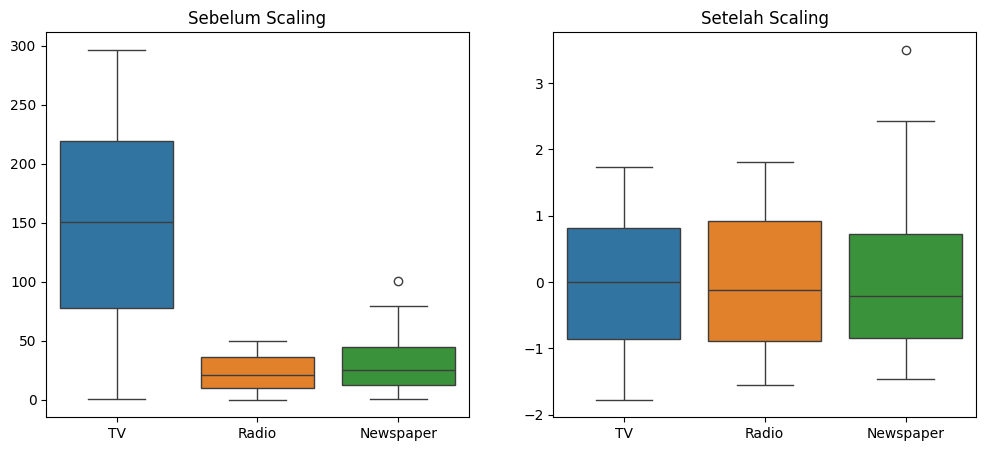

In [14]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio','Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")

plt.show()

In [23]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [16]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [17]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=1.0)
RMSE Train: 2.140203322325982
RMSE Test : 2.343866119206355
Coefficients: [3.63816587 0.57508535 0.        ]


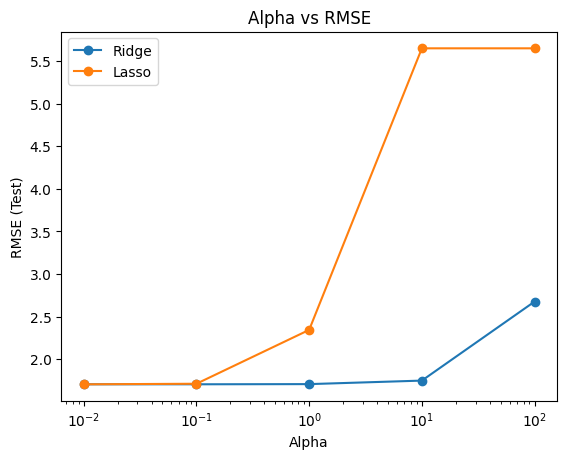

In [24]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))


plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

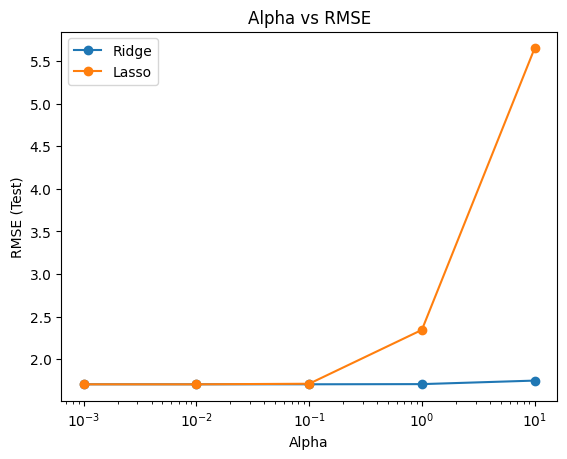

In [28]:
alphas = [0.001, 0.01, 0.1, 1, 10]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

In [29]:
coef_ridge = []
coef_lasso = []

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)
    coef_ridge.append(ridge.coef_)

    lasso = Lasso(alpha=l)
    lasso.fit(X_train_scaled, y_train)
    coef_lasso.append(lasso.coef_)

coef_ridge = np.array(coef_ridge)
coef_lasso = np.array(coef_lasso)

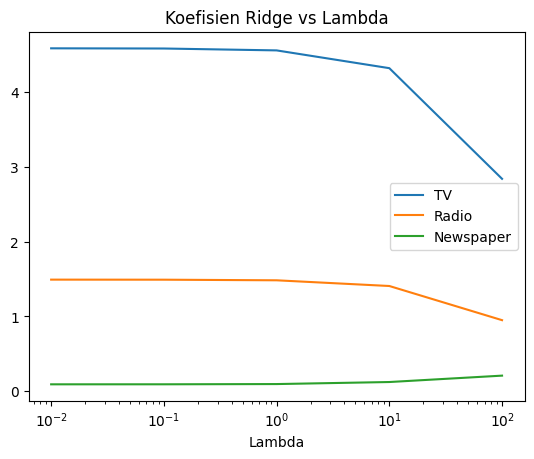

In [30]:
plt.figure()

for i in range(len(X.columns)):
    plt.plot(lambdas, coef_ridge[:, i], label=X.columns[i])

plt.xscale('log')
plt.title("Koefisien Ridge vs Lambda")
plt.xlabel("Lambda")
plt.legend()

plt.show()

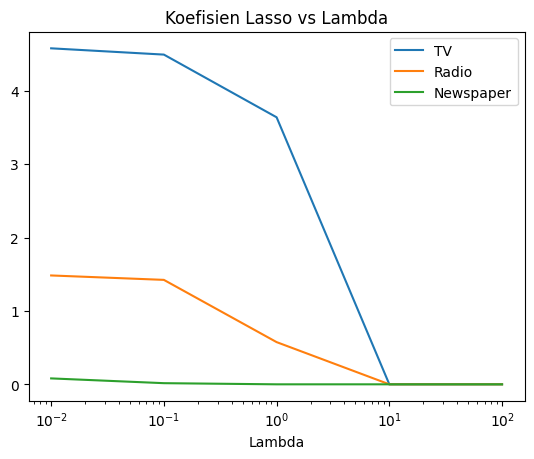

In [31]:
plt.figure()

for i in range(len(X.columns)):
    plt.plot(lambdas, coef_lasso[:, i], label=X.columns[i])

plt.xscale('log')
plt.title("Koefisien Lasso vs Lambda")
plt.xlabel("Lambda")
plt.legend()

plt.show()